In [1]:
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

In [2]:
# Carga de datos y diccionario
datos = pd.read_csv("./data.txt")
print(datos.head())
with open("./dict_data.txt", "r") as file:
    for line in file:
        print(line.strip())

   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0
| Column   Position 	| Atrribute Name 	| Definition                             	| Data Type    	| Example                              	| % Null Ratios 	|
|-------------------	|----------------	|----------------------------------------	|--------------	|--------------------------------------	|---------------	|
| 1                 	| No             	| No: row   number                       	| Quantitative 	| 22, 35, 48                           	| 0             	|
| 2                 	| Year           	| Year: year of   data in this 

In [3]:
# Analiss exploratorio de los datos
print(datos.info())
print(datos.describe())
print(datos.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB
None
                 No          year         month           day          hour  \
count  43824.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean   21912.500000   2012.000000      6.523549     15.727820     11.500000   
std    12651.043435      1.41384

In [4]:
# Manejo de datos nulos ( como representan menos del 5% de todas las observaciones, se eliminan) y eliminación primera columna
umbral = len(datos)*0.05
col_borrar = datos.columns[datos.isna().sum()<= umbral]
datos.dropna(subset=col_borrar, inplace=True)
print(datos.isna().sum())
datos = datos.drop(columns=datos.columns[0])
print(datos.head())

No       0
year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64
    year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd   Iws  Is  Ir
24  2010      1    2     0  129.0   -16  -4.0  1020.0   SE  1.79   0   0
25  2010      1    2     1  148.0   -15  -4.0  1020.0   SE  2.68   0   0
26  2010      1    2     2  159.0   -11  -5.0  1021.0   SE  3.57   0   0
27  2010      1    2     3  181.0    -7  -5.0  1022.0   SE  5.36   1   0
28  2010      1    2     4  138.0    -7  -5.0  1022.0   SE  6.25   2   0


In [5]:
# Análisis de los datos categóricos
print(datos['cbwd'].value_counts())
print(datos.groupby('cbwd')['Iws'].mean())

# Poseen una categoria adicional (cv) que no se encuentra en el diccionario, pero al relacionar las categorias con velocidad del viento (Iws), el resultado parece indicar que en estas observaciones la velocidad no es suficiente para determinar la direccion.  

cbwd
SE    14573
NW    13484
cv     8944
NE     4756
Name: count, dtype: int64
cbwd
NE     7.842454
NW    49.724987
SE    18.485031
cv     2.172516
Name: Iws, dtype: float64


In [6]:
# Adicion de una variable temporal para graficar.
datos['tiempo'] = pd.to_datetime(datos[['year', 'month', 'day', 'hour']])
print(datos.head())

    year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd   Iws  Is  Ir  \
24  2010      1    2     0  129.0   -16  -4.0  1020.0   SE  1.79   0   0   
25  2010      1    2     1  148.0   -15  -4.0  1020.0   SE  2.68   0   0   
26  2010      1    2     2  159.0   -11  -5.0  1021.0   SE  3.57   0   0   
27  2010      1    2     3  181.0    -7  -5.0  1022.0   SE  5.36   1   0   
28  2010      1    2     4  138.0    -7  -5.0  1022.0   SE  6.25   2   0   

                tiempo  
24 2010-01-02 00:00:00  
25 2010-01-02 01:00:00  
26 2010-01-02 02:00:00  
27 2010-01-02 03:00:00  
28 2010-01-02 04:00:00  


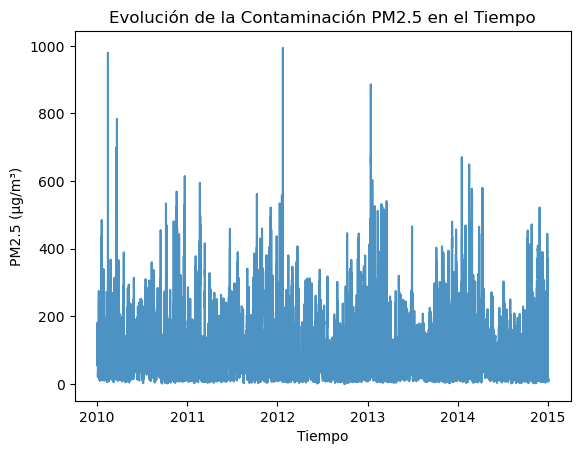

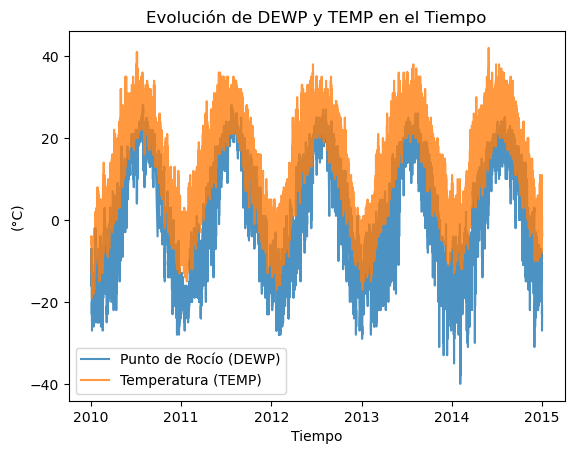

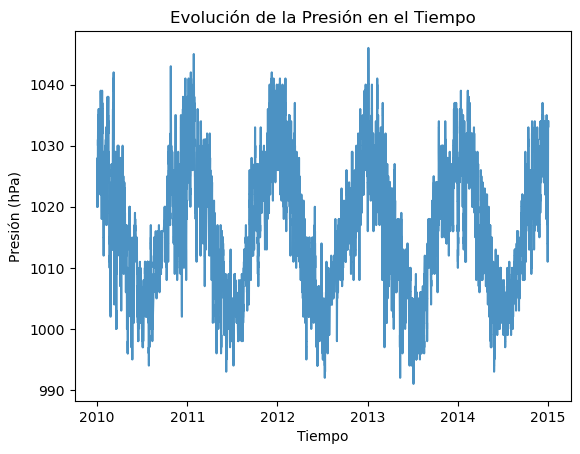

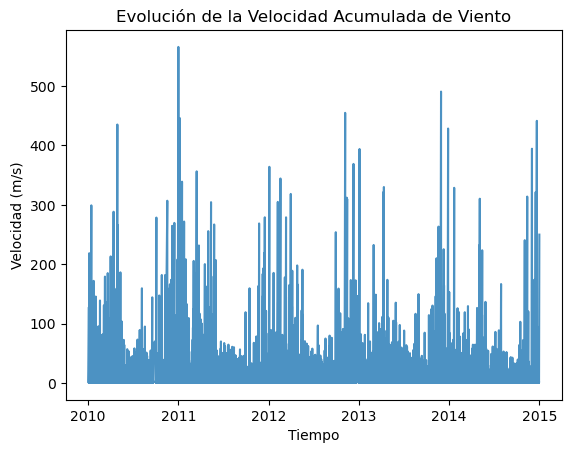

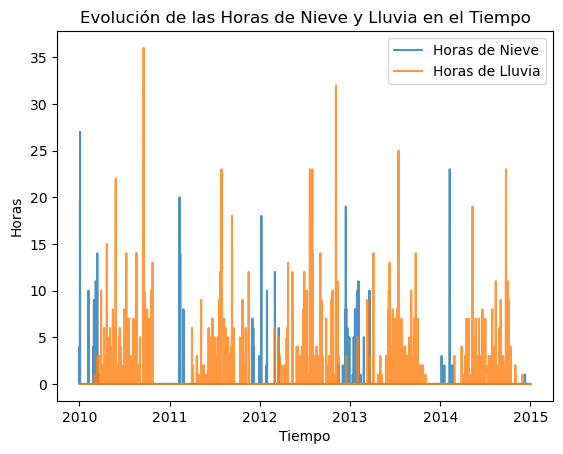

Text(0, 0.5, 'Velocidad Acumulada (m/s)')

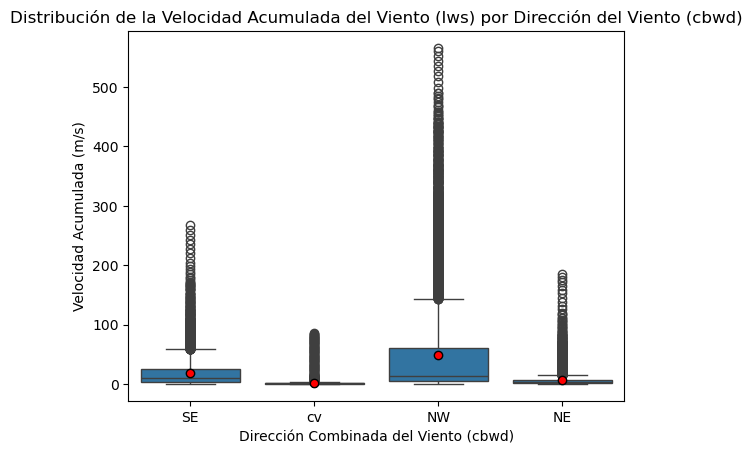

In [7]:
# Gráfico 1: Evolución de la Contaminación PM2.5
plt.figure()
sns.lineplot(x='tiempo', y='pm2.5', data=datos, alpha=0.8)
plt.title('Evolución de la Contaminación PM2.5 en el Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

# Gráfico 2: Evolución de DEWP y TEMP
plt.figure()
sns.lineplot(x='tiempo', y='DEWP', data=datos, alpha=0.8, label='Punto de Rocío (DEWP)')
sns.lineplot(x='tiempo', y='TEMP', data=datos, alpha=0.8, label='Temperatura (TEMP)')
plt.title('Evolución de DEWP y TEMP en el Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('(°C)')
plt.show()

# Gráfico 3: Evolución de la Presión
plt.figure()
sns.lineplot(x='tiempo', y='PRES', data=datos, alpha=0.8)
plt.title('Evolución de la Presión en el Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Presión (hPa)')
plt.show()

# Gráfico 4: Evolución de la Velocidad del Viento (Iws)
plt.figure()
sns.lineplot(x='tiempo', y='Iws', data=datos, alpha=0.8)
plt.title('Evolución de la Velocidad Acumulada de Viento')
plt.xlabel('Tiempo')
plt.ylabel('Velocidad (m/s)')
plt.show()

# Gráfico 5: Evolución de Is e Iw
plt.figure()
sns.lineplot(x='tiempo',y='Is',data=datos, alpha=0.8, label='Horas de Nieve')
sns.lineplot(x='tiempo',y='Ir',data=datos, alpha=0.8, label='Horas de Lluvia')
plt.title('Evolución de las Horas de Nieve y Lluvia en el Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Horas')
plt.show()

# Gráfico 6: cbwd vs Iws
plt.figure()
sns.boxplot(x='cbwd', y='Iws', data=datos, showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})
plt.title('Distribución de la Velocidad Acumulada del Viento (Iws) por Dirección del Viento (cbwd)')
plt.xlabel('Dirección Combinada del Viento (cbwd)')
plt.ylabel('Velocidad Acumulada (m/s)')


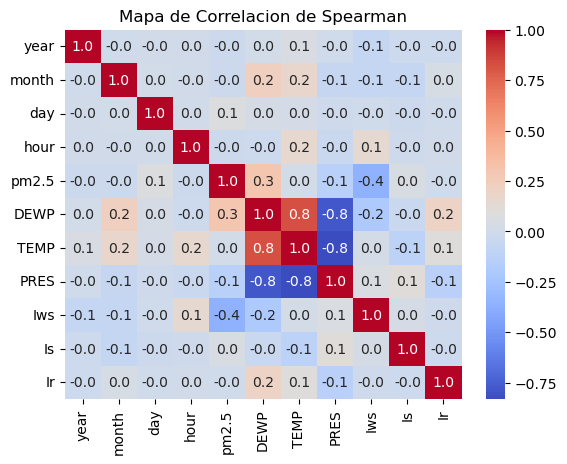

year
2010    104.045730
2011     99.071340
2012     90.545871
2013    101.712376
2014     97.734557
Name: pm2.5, dtype: float64


In [8]:
# Correlación de variables numéricas
datos_numericos = datos.select_dtypes(include=['number'])
plt.figure()
sns.heatmap(datos_numericos.corr('spearman'), annot=True, fmt='.1f', cmap='coolwarm', cbar=True)
plt.title('Mapa de Correlacion de Spearman')
plt.show()

# Analisis de la variable año, si varia el promedio de pm2.5 a traves de los años (importancia de la variable para el modelo) 
print(datos.groupby('year')['pm2.5'].mean())

In [9]:
# Creación de una nueva columna para categoria de pm2.5
bins = [0, 12, 35, 55, 150, 250, np.inf]
labels = ['Buena', 'Moderada', 'Insalubre para sensibles', 'Insalubre', 'Muy insalubre', 'Peligroso']
datos['pm2.5_rango'] = pd.cut(datos['pm2.5'], bins=bins, labels=labels)
print(datos.head())
umbral = len(datos)*0.05
col_borrar = datos.columns[datos.isna().sum()<= umbral]
datos.dropna(subset=col_borrar, inplace=True)

    year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd   Iws  Is  Ir  \
24  2010      1    2     0  129.0   -16  -4.0  1020.0   SE  1.79   0   0   
25  2010      1    2     1  148.0   -15  -4.0  1020.0   SE  2.68   0   0   
26  2010      1    2     2  159.0   -11  -5.0  1021.0   SE  3.57   0   0   
27  2010      1    2     3  181.0    -7  -5.0  1022.0   SE  5.36   1   0   
28  2010      1    2     4  138.0    -7  -5.0  1022.0   SE  6.25   2   0   

                tiempo    pm2.5_rango  
24 2010-01-02 00:00:00      Insalubre  
25 2010-01-02 01:00:00      Insalubre  
26 2010-01-02 02:00:00  Muy insalubre  
27 2010-01-02 03:00:00  Muy insalubre  
28 2010-01-02 04:00:00      Insalubre  


In [10]:
# Modelo random forest

# Selección de variables para el modelo

X = datos[['year','month','day','hour']]
y = datos['pm2.5_rango']


# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo de clasificación
modelo = RandomForestClassifier(class_weight='balanced')
modelo.fit(X_train, y_train)

# Predicción
y_pred = modelo.predict(X_test)
print("Predicciones:", y_pred)
from sklearn.metrics import classification_report

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Validación cruzada
scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"Precisión promedio con validación cruzada: {np.mean(scores):.3f}")

# Importancia de características
importances = modelo.feature_importances_
for feature, importance in zip(X.columns, importances):
    print(f"{feature}: {importance:.4f}")

Predicciones: ['Insalubre para sensibles' 'Moderada' 'Peligroso' ... 'Muy insalubre'
 'Insalubre' 'Insalubre']
Reporte de Clasificación:
                          precision    recall  f1-score   support

                   Buena       0.70      0.65      0.67       666
               Insalubre       0.80      0.88      0.84      3109
Insalubre para sensibles       0.62      0.52      0.57      1028
                Moderada       0.75      0.75      0.75      1771
           Muy insalubre       0.77      0.73      0.75      1174
               Peligroso       0.87      0.83      0.85       603

                accuracy                           0.77      8351
               macro avg       0.75      0.73      0.74      8351
            weighted avg       0.76      0.77      0.76      8351

Precisión promedio con validación cruzada: 0.724
year: 0.1284
month: 0.1567
day: 0.4288
hour: 0.2861


In [11]:
 with open('modelo_polucion.pkl', 'wb') as f:
     pickle.dump(modelo, f)